In [12]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import scipy
from sandbox.jordan5 import setup_device
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sandbox.jordan7 import *

import json

# Training

In [3]:
torch.manual_seed(0)
np.random.seed(0)

d = 28

model = JordanNet(d=d, num_classes=d, encode_dim=32)

matrices, labels, features, masks, dists = generate_training_dataset(
    matrices_per_class=5_000,
    d=d,
    mode="random",
    device="cpu",
    numpy_float32=True,
)

print(dists.mean(dim=0))
print(dists.std(dim=0))
print(dists.max(), dists.min())

model = train_jordan_net(
    model,
    features,
    masks,
    dists,
    num_epochs=20,
    batch_size=64,
    device=device,
)

Generating class with max_block_size=1...Done.
Generating class with max_block_size=2...Done.
Generating class with max_block_size=3...Done.
Generating class with max_block_size=4...Done.
Generating class with max_block_size=5...Done.
Generating class with max_block_size=6...Done.
Generating class with max_block_size=7...Done.
Generating class with max_block_size=8...Done.
Generating class with max_block_size=9...Done.
Generating class with max_block_size=10...Done.
Generating class with max_block_size=11...Done.
Generating class with max_block_size=12...Done.
Generating class with max_block_size=13...Done.
Generating class with max_block_size=14...Done.
Generating class with max_block_size=15...Done.
Generating class with max_block_size=16...Done.
Generating class with max_block_size=17...Done.
Generating class with max_block_size=18...Done.
Generating class with max_block_size=19...Done.
Generating class with max_block_size=20...Done.
Generating class with max_block_size=21...Done.
G

c:\Users\micha\Documents\Studia\Magisterka\sandbox\jordan7.py:323: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan7_{d}

Epoch [1/20] | Train Loss: 0.173658 | Val Loss: 0.176625
Epoch [2/20] | Train Loss: 0.158427 | Val Loss: 0.185381
Epoch [3/20] | Train Loss: 0.154220 | Val Loss: 0.177304
Epoch [4/20] | Train Loss: 0.148324 | Val Loss: 0.202257
Early stopping triggered at epoch 4. Best Val Loss: 0.176625


c:\Users\micha\Documents\Studia\Magisterka\sandbox\jordan7.py:385: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan7_{d}

# Tests

In [25]:
def run_test(model, d, matrices_per_class=1000, mode="random", eps=None, eps_range=None):
    model.eval()

    matrices_test, labels_test, features_test, masks_test, dists_test = generate_training_dataset(
        matrices_per_class=matrices_per_class,
        d=d,
        mode=mode,
        eps=eps,
        eps_range=eps_range,
        device="cpu",
    )

    loader = DataLoader(TensorDataset(features_test, labels_test, masks_test, dists_test), batch_size=64, shuffle=False)

    predicted_classes = []
    true_classes = labels_test.cpu().tolist()
    kl_avg = 0.0

    for batch_features, batch_labels, batch_masks, batch_dists in loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        batch_masks = batch_masks.to(device)
        batch_dists = batch_dists.to(device)

        logits = model(batch_features, masks=batch_masks)
        # logits = model(batch_features, masks=None)
        loss = kl_loss(logits, batch_dists)

        preds = torch.argmax(logits, dim=-1)
        predicted_classes += preds.cpu().tolist()
        kl_avg += loss.item() * batch_features.size(0)

    kl_avg /= len(loader.dataset)
    # print(f"Test KL Loss: {kl_avg:.6f}")

    return true_classes, predicted_classes, kl_avg

def test_jordan_net(model, d, matrices_per_class=1000, filename=None):
    if filename is None:
        filename = f"sandbox/jordan7_results/results_{d}.json"

    results = []

    for eps in [0.0, 1e-6, 1e-4, 1e-2, 1e-1, 1]:
        print(f"Testing with eps={eps}")
        true_classes, predicted_classes, kl_avg = run_test(model, d, matrices_per_class=matrices_per_class, mode="random", eps=eps)
        results.append({
            "eps": eps,
            "true_classes": true_classes,
            "predicted_classes": predicted_classes,
            "kl_avg": kl_avg,
        })
    
    print(f"Testing mode 'ortho'")
    true_classes, predicted_classes, kl_avg = run_test(model, d, matrices_per_class=matrices_per_class, mode="ortho", eps=0.0)
    results.append({
        "eps": "ortho",
        "true_classes": true_classes,
        "predicted_classes": predicted_classes,
        "kl_avg": kl_avg,
    })
    with open(filename, "w") as f:
        json.dump(results, f, indent=4)
    
def visualize_test_results(d, filename):
    with open(filename, "r") as f:
        results = json.load(f) 
    
    for result in results:
        eps = result["eps"]
        true_classes = result["true_classes"]
        predicted_classes = result["predicted_classes"]
        
        cm = confusion_matrix(true_classes, predicted_classes, labels=list(range(d)))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1, d+1)))
        disp.plot(cmap=plt.cm.Blues)
        title = f"{'eps='+str(eps) if eps != 'ortho' else 'ortho'}. KL Loss: {result['kl_avg']:.6f}, accuracy: {np.trace(cm) / np.sum(cm):.4f}"
        plt.title(title)
        plt.show()

In [29]:
d = 15
model = JordanNet(d=d, num_classes=d, encode_dim=32)
model.load_state_dict(torch.load(f"sandbox/model_jordan7_{d}.pth"))
model.to(device)
test_jordan_net(model, d, matrices_per_class=1000)

Testing with eps=0.0
Generating class with max_block_size=1...

C:\Users\micha\AppData\Local\Temp\ipykernel_13092\784566313.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan7_{d}.

Done.
Generating class with max_block_size=2...Done.
Generating class with max_block_size=3...Done.
Generating class with max_block_size=4...Done.
Generating class with max_block_size=5...Done.
Generating class with max_block_size=6...Done.
Generating class with max_block_size=7...Done.
Generating class with max_block_size=8...Done.
Generating class with max_block_size=9...Done.
Generating class with max_block_size=10...Done.
Generating class with max_block_size=11...Done.
Generating class with max_block_size=12...Done.
Generating class with max_block_size=13...Done.
Generating class with max_block_size=14...Done.
Generating class with max_block_size=15...Done.
Testing with eps=1e-06
Generating class with max_block_size=1...Done.
Generating class with max_block_size=2...Done.
Generating class with max_block_size=3...Done.
Generating class with max_block_size=4...Done.
Generating class with max_block_size=5...Done.
Generating class with max_block_size=6...Done.
Generating class with max

# Results

#### d = 28

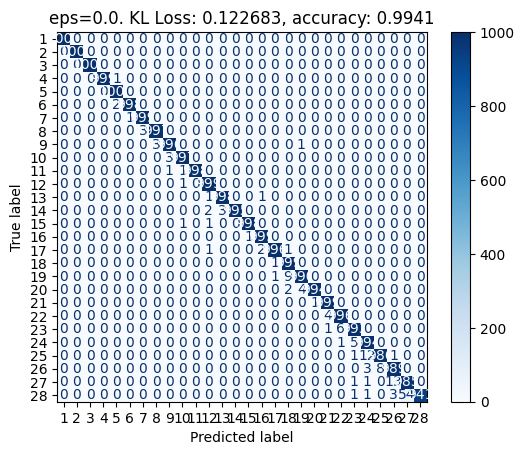

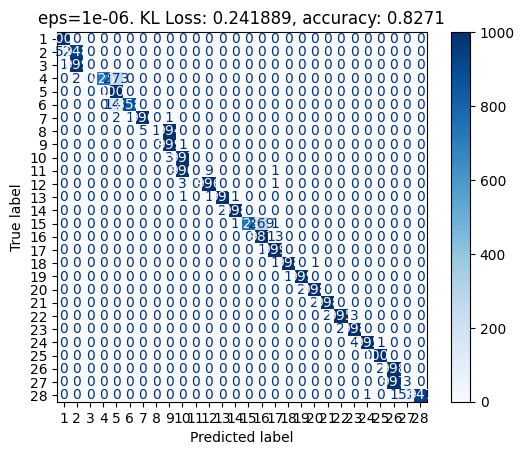

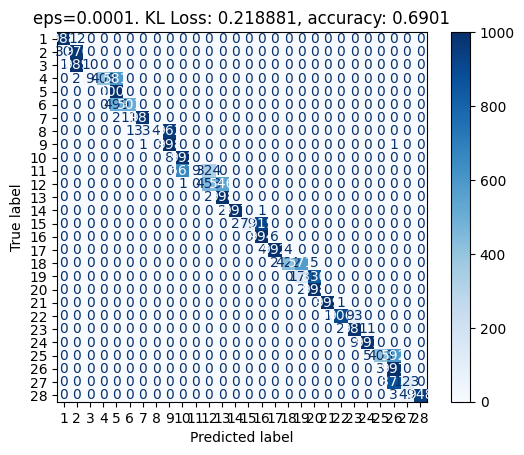

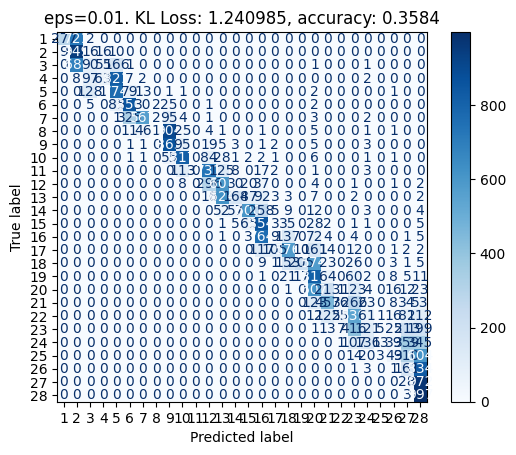

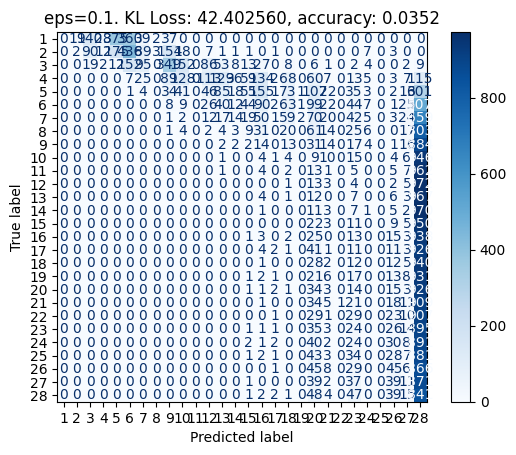

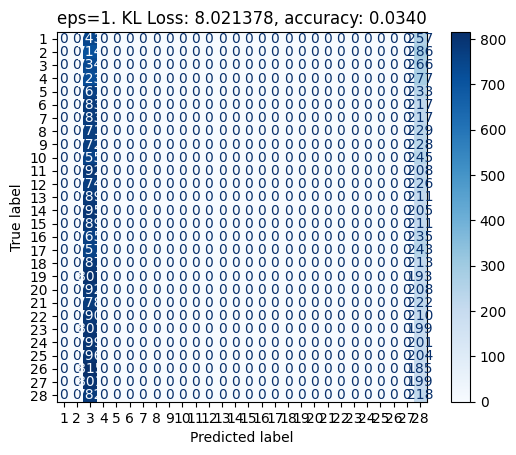

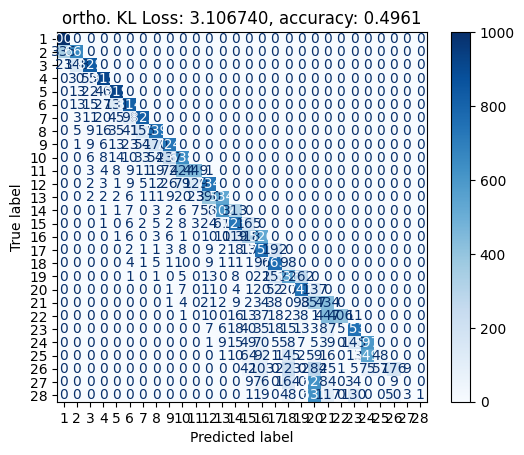

In [28]:
d=28
visualize_test_results(d, f"sandbox/jordan7_results/results_{d}.json")

C:\Users\micha\AppData\Local\Temp\ipykernel_13092\190466177.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan7_{d}.

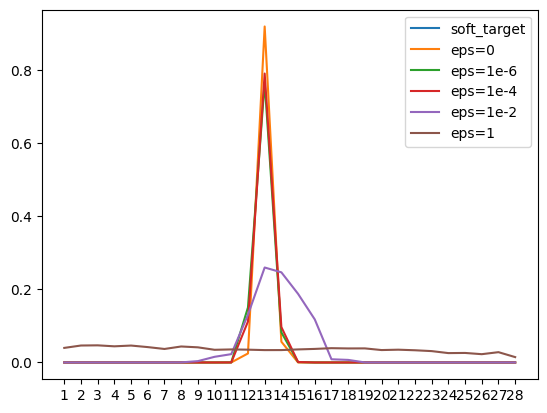

In [4]:
d = 28

model = JordanNet(d=d, num_classes=d, encode_dim=32)

model.load_state_dict(torch.load(f"sandbox/model_jordan7_{d}.pth"))

max_block_size = 13

Xs = [generate_matrix(d, max_block_size, mode="random", eps=eps) for eps in [0, 1e-6, 1e-4, 1e-2, 1]]
X_batch = torch.tensor(Xs, dtype=torch.float32)
features = [per_power_features(X) for X in Xs]
X_features = torch.tensor([f[0] for f in features], dtype=torch.float32)
masks = torch.tensor([f[1] for f in features], dtype=torch.float32)

model.eval()
logits = model(X_features.to(device), masks=masks.to(device))
# logits = model(X_features.to(device), masks=None)
probs = torch.softmax(logits, dim=-1)
probs = probs.detach().cpu().numpy()

plt.plot(soft_target(torch.tensor([max_block_size]), eps=torch.tensor(1e-4), d=d).cpu().numpy()[0], label="soft_target")

for prob, label in zip(probs, ["eps=0", "eps=1e-6", "eps=1e-4", "eps=1e-2", "eps=1"]):
    plt.plot(prob, label=label)
plt.legend()
plt.xticks(ticks=range(d), labels=range(1,d+1))
plt.show()

#### d = 15

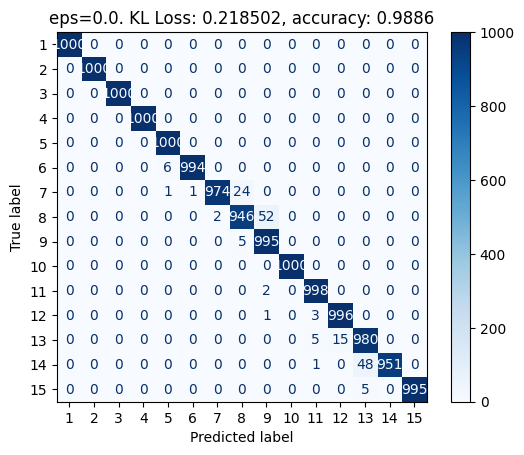

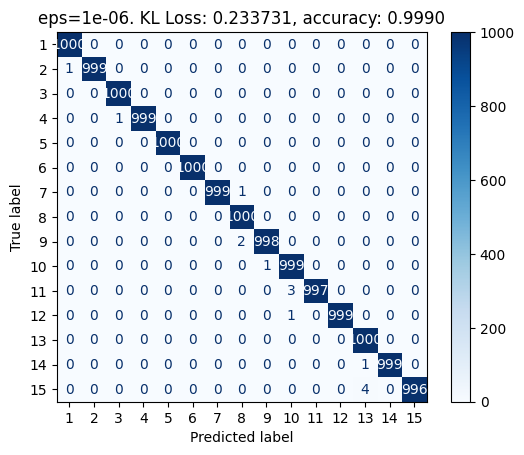

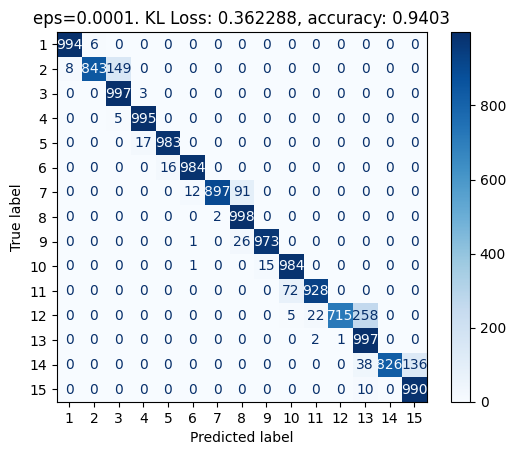

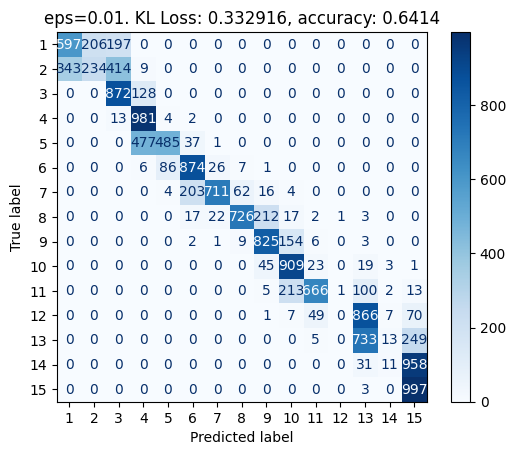

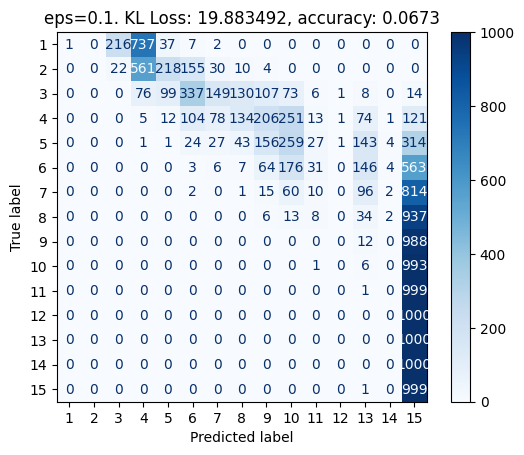

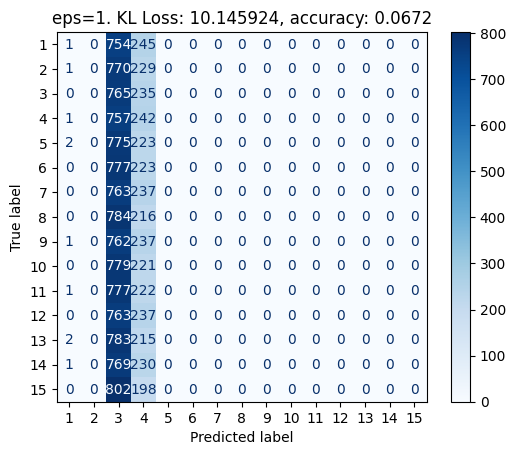

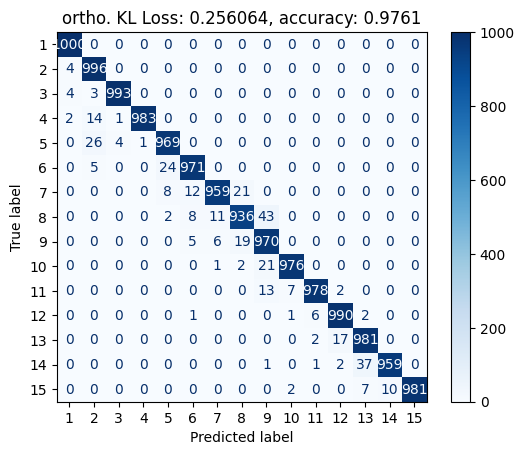

In [30]:
d=15
visualize_test_results(d, f"sandbox/jordan7_results/results_{d}.json")